# Lorenz63 MLP Residual Training Cookbook

This notebook trains the current `models.py` MLP residual Neural ODE model. The model uses an unconstrained learnable linear matrix plus an MLP residual component:

`f_theta(x) = A_theta x + G_theta(x)`

The default residual mask in `models.py` is `(1, 1, 1)`, so the residual component is not told the Lorenz63 nonlinear sparsity constraint.

In [28]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from torch.optim import AdamW

repo_root = Path.cwd()
if repo_root.name == "examples":
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lorenz63_neuralode.data import get_dataloaders
from lorenz63_neuralode.models import build_lorenz63_model

torch.manual_seed(42)
plt.rcParams.update({"figure.dpi": 120})

repo_root

PosixPath('/srv/data/kezhoulumelody/Lorenz63_NeuralODE')

## Configuration

`MODEL_NAME = "residual_mlp"` builds `Lorenz63ResidualModel` from the current unstructured `models.py`.

In [29]:
MODEL_NAME = "residual_mlp"

DATA_PATH = repo_root / "data" / "lorenz63_trajectory_10-28-2.7.npz"


SIGMA_INIT = 10.0
RHO_INIT = 28
BETA_INIT = 2.7
HIDDEN_DIM = 64
N_HIDDEN_LAYERS = 1

BATCH_SIZE = 256
N_EPOCHS = 400
LR = 1e-3
WEIGHT_DECAY = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR = repo_root / "outputs" / "unstructured" / f"lorenz63_{MODEL_NAME}.hidden{HIDDEN_DIM}.layers{N_HIDDEN_LAYERS}.normalizedLoss"

# OUTPUT_DIR = repo_root / "outputs" / "unstructured" / f"lorenz63_{MODEL_NAME}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_ARTIFACTS = True
CHECKPOINT_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_10-28-2.7_{SIGMA_INIT}-{RHO_INIT}-{BETA_INIT}.pt"
CURVE_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_10-28-2.7_{SIGMA_INIT}-{RHO_INIT}-{BETA_INIT}_curves.png"

print(f"device: {DEVICE}")
print(f"data: {DATA_PATH}")
print(f"output: {OUTPUT_DIR}")

device: cuda
data: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/data/lorenz63_trajectory_10-28-2.7.npz
output: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp.hidden64.layers1.normalizedLoss


## Load Data And Build Model

In [30]:
train_loader, test_loader = get_dataloaders(
    npz_path=DATA_PATH,
    batch_size=BATCH_SIZE,
)

model = build_lorenz63_model(
    model_name=MODEL_NAME,
    sigma_init=SIGMA_INIT,
    rho_init=RHO_INIT,
    beta_init=BETA_INIT,
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_train = len(train_loader.dataset)
n_test = len(test_loader.dataset)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"train samples: {n_train}, test samples: {n_test}")
print(f"trainable parameters: {n_params}")
print(f"initial learned A:\n{model.A.detach().cpu()}")
print(f"residual mask: {model.residual_mask.detach().cpu().tolist()}")


Lorenz63ResidualModel(
  (linear): UnstructuredLorenz63Linear()
  (residual_net): ResidualMLP(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=3, bias=True)
    )
  )
)
train samples: 80000, test samples: 20000
trainable parameters: 460
initial learned A:
tensor([[-10.0000,  10.0000,   0.0000],
        [ 28.0000,  -1.0000,   0.0000],
        [  0.0000,   0.0000,  -2.7000]])
residual mask: [1.0, 1.0, 1.0]


## Metric Helpers

`compute_tendency_component_scale` mirrors `train.py`: it computes the training-set standard deviation of `dx/dt`, `dy/dt`, and `dz/dt` so the loss can normalize each component before taking MSE.

`evaluate_split` returns overall RMSE, component-wise RMSE for `dx/dt`, `dy/dt`, and `dz/dt`, plus overall and component-wise anomaly correlation coefficient.

In [31]:
def compute_tendency_component_scale(train_loader, device, eps=1e-8):
    """Compute per-component target tendency scales from the training split."""
    total = torch.zeros(3, device=device)
    total_sq = torch.zeros(3, device=device)
    n_samples = 0

    for batch in train_loader:
        target_dxdt = batch["dxdt"].to(device)
        total += torch.sum(target_dxdt, dim=0)
        total_sq += torch.sum(target_dxdt ** 2, dim=0)
        n_samples += target_dxdt.shape[0]

    if n_samples == 0:
        raise ValueError("Cannot compute tendency component scales from an empty train loader.")

    mean = total / n_samples
    variance = torch.clamp(total_sq / n_samples - mean ** 2, min=eps ** 2)
    return torch.sqrt(variance)


@torch.no_grad()
def evaluate_split(model, dataloader, device):
    model.eval()
    preds = []
    targets = []

    for batch in dataloader:
        state = batch["state"].to(device)
        target = batch["dxdt"].to(device)
        pred = model(state)
        preds.append(pred.detach().cpu())
        targets.append(target.detach().cpu())

    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    err = pred - target

    eps = 1e-12
    rmse = torch.sqrt(torch.mean(err ** 2))
    component_rmse = torch.sqrt(torch.mean(err ** 2, dim=0))

    target_mean = torch.mean(target, dim=0, keepdim=True)
    pred_anom = pred - target_mean
    target_anom = target - target_mean

    acc_numerator = torch.sum(pred_anom * target_anom)
    acc_denominator = torch.sqrt(torch.sum(pred_anom ** 2) * torch.sum(target_anom ** 2)).clamp_min(eps)
    acc = acc_numerator / acc_denominator

    component_acc_numerator = torch.sum(pred_anom * target_anom, dim=0)
    component_acc_denominator = torch.sqrt(
        torch.sum(pred_anom ** 2, dim=0) * torch.sum(target_anom ** 2, dim=0)
    ).clamp_min(eps)
    component_acc = component_acc_numerator / component_acc_denominator

    return {
        "rmse": float(rmse),
        "component_rmse": [float(v) for v in component_rmse],
        "acc": float(acc),
        "component_acc": [float(v) for v in component_acc],
    }


def append_metrics(history, prefix, metrics):
    history[f"{prefix}_rmse"].append(metrics["rmse"])
    history[f"{prefix}_component_rmse"].append(metrics["component_rmse"])
    history[f"{prefix}_acc"].append(metrics["acc"])
    history[f"{prefix}_component_acc"].append(metrics["component_acc"])

## Train

The loop uses normalized component tendency MSE for optimization, while evaluation metrics remain in the original physical units. It evaluates both train and test splits after each epoch so the curves below show in-sample and out-of-sample behavior.

In [32]:
component_scale = compute_tendency_component_scale(train_loader, DEVICE)
print(
    "Training with normalized tendency MSE using component scales: "
    f"{component_scale[0]:.6f}, {component_scale[1]:.6f}, {component_scale[2]:.6f}"
)

history = {
    "epoch": [],
    "train_loss": [],
    "train_normalized_rmse": [],
    "train_rmse": [],
    "test_rmse": [],
    "train_component_rmse": [],
    "test_component_rmse": [],
    "train_acc": [],
    "test_acc": [],
    "train_component_acc": [],
    "test_component_acc": [],
}

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    n_samples = 0

    for batch in train_loader:
        state = batch["state"].to(DEVICE)
        target = batch["dxdt"].to(DEVICE)

        pred = model(state)
        normalized_error = (pred - target) / component_scale
        loss = torch.mean(normalized_error ** 2)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_n = state.shape[0]
        total_loss += loss.item() * batch_n
        n_samples += batch_n

    train_loss = total_loss / max(n_samples, 1)
    train_normalized_rmse = train_loss ** 0.5
    train_metrics = evaluate_split(model, train_loader, DEVICE)
    test_metrics = evaluate_split(model, test_loader, DEVICE)

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["train_normalized_rmse"].append(float(train_normalized_rmse))
    append_metrics(history, "train", train_metrics)
    append_metrics(history, "test", test_metrics)

    if epoch == 1 or epoch % 10 == 0 or epoch == N_EPOCHS:
        print(
            f"epoch {epoch:04d} | "
            f"normalized loss {train_loss:.6f} | "
            f"normalized RMSE {train_normalized_rmse:.6f} | "
            f"train RMSE {train_metrics['rmse']:.6f} | "
            f"test RMSE {test_metrics['rmse']:.6f} | "
            f"train ACC {train_metrics['acc']:.4f} | "
            f"test ACC {test_metrics['acc']:.4f}"
        )


Training with normalized tendency MSE using component scales: 43.112057, 66.142014, 79.642296
epoch 0001 | normalized loss 4.940746 | normalized RMSE 2.222779 | train RMSE 145.475037 | test RMSE 144.253983 | train ACC -0.1409 | test ACC -0.1271
epoch 0010 | normalized loss 1.883754 | normalized RMSE 1.372499 | train RMSE 91.331459 | test RMSE 90.275513 | train ACC -0.0417 | test ACC -0.0278
epoch 0020 | normalized loss 0.671012 | normalized RMSE 0.819153 | train RMSE 55.965530 | test RMSE 55.318729 | train ACC 0.5079 | test ACC 0.5182
epoch 0030 | normalized loss 0.236629 | normalized RMSE 0.486445 | train RMSE 34.323414 | test RMSE 33.992165 | train ACC 0.8750 | test ACC 0.8767
epoch 0040 | normalized loss 0.098377 | normalized RMSE 0.313651 | train RMSE 22.336834 | test RMSE 22.158072 | train ACC 0.9524 | test ACC 0.9528
epoch 0050 | normalized loss 0.042602 | normalized RMSE 0.206403 | train RMSE 14.661084 | test RMSE 14.551172 | train ACC 0.9785 | test ACC 0.9786
epoch 0060 | norma

## Learning Curves

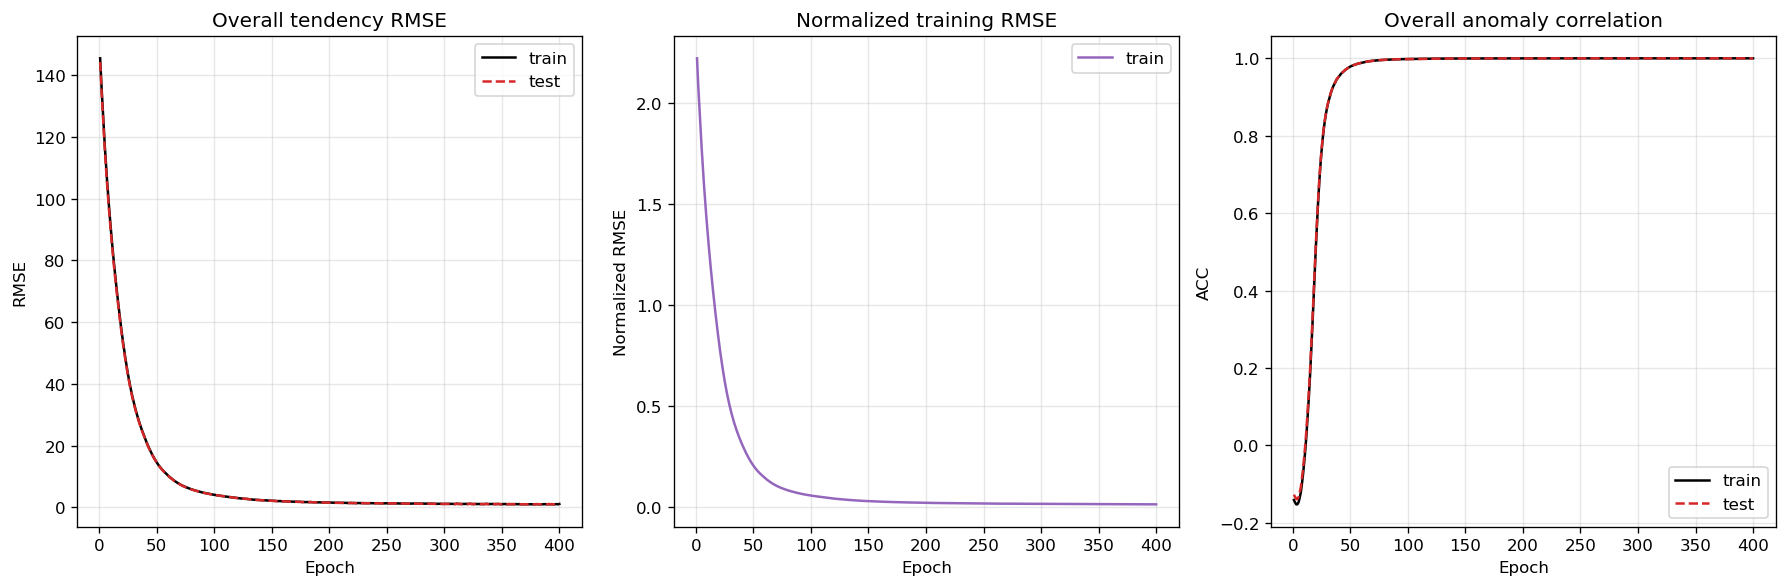

In [33]:
epochs = history["epoch"]
component_names = ("dx/dt", "dy/dt", "dz/dt")
component_colors = ("tab:blue", "tab:orange", "tab:green")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(epochs, history["train_rmse"], label="train", color="black")
axes[0].plot(epochs, history["test_rmse"], label="test", color="tab:red", linestyle="--")
axes[0].set_title("Overall tendency RMSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_normalized_rmse"], label="train", color="tab:purple")
axes[1].set_title("Normalized training RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Normalized RMSE")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history["train_acc"], label="train", color="black")
axes[2].plot(epochs, history["test_acc"], label="test", color="tab:red", linestyle="--")
axes[2].set_title("Overall anomaly correlation")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("ACC")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.tight_layout()
# if SAVE_ARTIFACTS:
#     fig.savefig(CURVE_PATH, dpi=200)
#     print(f"saved curves to {CURVE_PATH}")
plt.show()


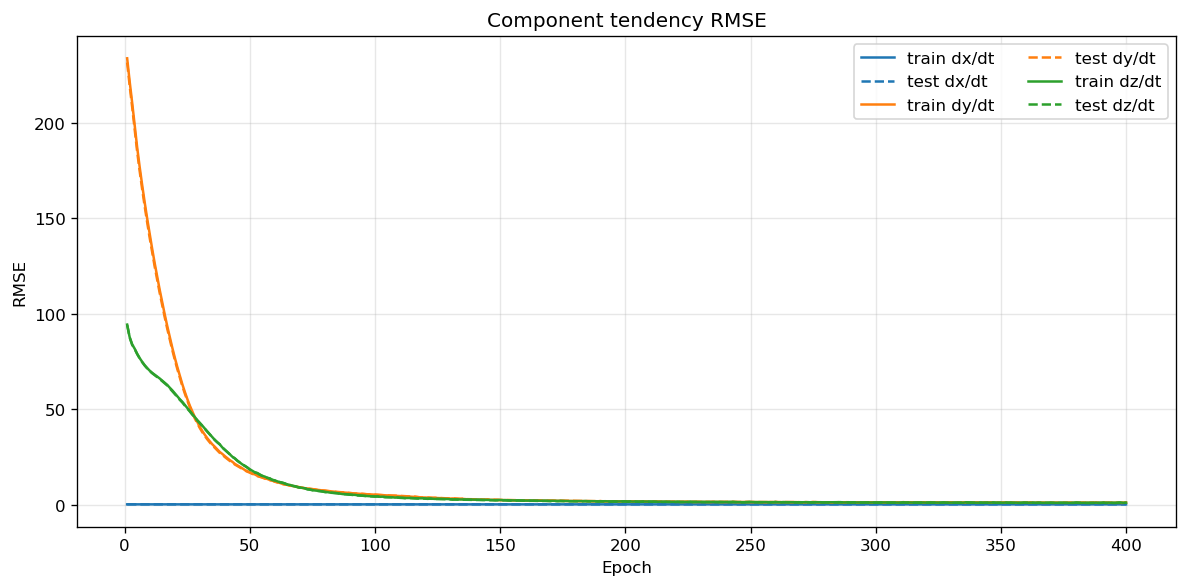

In [34]:
train_component_rmse = torch.tensor(history["train_component_rmse"])
test_component_rmse = torch.tensor(history["test_component_rmse"])

fig, ax = plt.subplots(figsize=(10, 5))

for idx, (name, color) in enumerate(zip(component_names, component_colors)):
    ax.plot(epochs, train_component_rmse[:, idx], label=f"train {name}", color=color)
    ax.plot(epochs, test_component_rmse[:, idx], label=f"test {name}", color=color, linestyle="--")

ax.set_title("Component tendency RMSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.legend(ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Final Metrics

In [35]:
final = {
    "train_normalized_rmse": history["train_normalized_rmse"][-1],
    "train_rmse": history["train_rmse"][-1],
    "test_rmse": history["test_rmse"][-1],
    "train_acc": history["train_acc"][-1],
    "test_acc": history["test_acc"][-1],
    "train_component_rmse": dict(zip(component_names, history["train_component_rmse"][-1])),
    "test_component_rmse": dict(zip(component_names, history["test_component_rmse"][-1])),
}

final


{'train_normalized_rmse': 0.014780306997220136,
 'train_rmse': 1.1169140338897705,
 'test_rmse': 1.116242527961731,
 'train_acc': 0.9998519420623779,
 'test_acc': 0.9998509883880615,
 'train_component_rmse': {'dx/dt': 0.40047982335090637,
  'dy/dt': 1.39266037940979,
  'dz/dt': 1.2816412448883057},
 'test_component_rmse': {'dx/dt': 0.39992624521255493,
  'dy/dt': 1.419013261795044,
  'dz/dt': 1.250780701637268}}

## Save Checkpoint

In [36]:
if SAVE_ARTIFACTS:
    checkpoint_params = {
        "model_name": MODEL_NAME,
        "sigma_init": SIGMA_INIT,
        "rho_init": RHO_INIT,
        "beta_init": BETA_INIT,
        "hidden_dim": HIDDEN_DIM,
        "n_hidden_layers": N_HIDDEN_LAYERS,
        "residual_mask": model.residual_mask.detach().cpu(),
        "learned_A": model.A.detach().cpu() if hasattr(model, "A") else None,
        "tendency_component_scale": component_scale.detach().cpu(),
    }

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "history": history,
            "params": checkpoint_params,
        },
        CHECKPOINT_PATH,
    )
    print(f"saved checkpoint to {CHECKPOINT_PATH}")
    print("saved params:")
    print(checkpoint_params)

saved checkpoint to /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp.hidden64.layers1.normalizedLoss/lorenz63_residual_mlp_10-28-2.7_10.0-28-2.7.pt
saved params:
{'model_name': 'residual_mlp', 'sigma_init': 10.0, 'rho_init': 28, 'beta_init': 2.7, 'hidden_dim': 64, 'n_hidden_layers': 1, 'residual_mask': tensor([1., 1., 1.]), 'learned_A': tensor([[-9.9049,  9.8854,  0.0464],
        [13.9636, -2.4973,  0.5439],
        [-0.1136,  0.3310, -2.9037]]), 'tendency_component_scale': tensor([43.1121, 66.1420, 79.6423])}
